In [18]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# Ex. 1 - Diffusion-reaction

Diffusion-reaction problem in the unit square domain $\Omega = {(0,1)}^2$, with Neumann boundary conditions:
\begin{equation*}
  \begin{cases}
    -\Delta u + 3 u = 2(y^2-1)e^{-x}, \qquad & \text{in }\Omega, \\
    \nabla u\cdot{\boldsymbol{n}} = -y^2 \qquad & \text{on }\Gamma_1 = \{x=0, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = y^2 \qquad & \text{on }\Gamma_2 = \{x=1, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 0 \qquad & \text{on }\Gamma_3 = \{0\leq x\leq 1, y=0\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 1 \qquad & \text{on }\Gamma_4 = \{0\leq x\leq 1, y=1\}.\end{cases}
\end{equation*}

The numbers of $\Gamma_i$ correspond to the tags that *UnitSquareMesh* automatically assign to the four edges, used by *ds* (see below).

In [2]:
from firedrake import *
import numpy as np
import matplotlib.pyplot as plt

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-0.05), np.float64(1.05), np.float64(-0.05), np.float64(1.05))

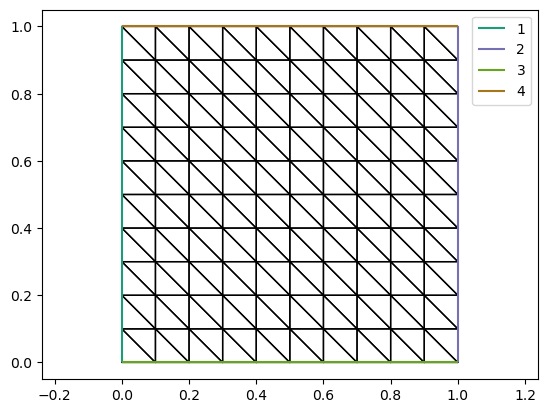

In [5]:
N = 10
# Build the mesh
mesh = UnitSquareMesh(N, N, diagonal='left')

# Plot it
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend()
ax.axis('equal')

In [6]:
# Define a discrete function space
V = FunctionSpace(mesh, 'P', 1)

# Define trial and test functions as belonging to the space
u = TrialFunction(V)
v = TestFunction(V)

# Define the right-hand side
x = SpatialCoordinate(mesh)
f = 2*((x[1]**2)-1)*exp(-x[0])

# Define the variational problem: bilinear form and rhs
a = dot(grad(u), grad(v)) * dx + 3*u*v*dx
L = f*v*dx - (x[1]**2)*v*ds(1) + (x[1]**2)*v*ds(2) + v*ds(4)

u_h = Function(V)
solve(a == L, u_h)

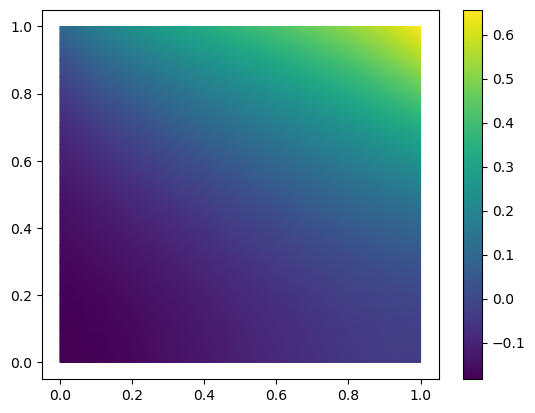

In [7]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h, axes=ax)
fig.colorbar(q)

#### point 4 - Algebraic formulation

In [8]:
A = assemble(a)
rhs = assemble(L)

solver = LinearSolver(A,
                      solver_parameters={'ksp_type': 'preonly',
                                         'pc_type': 'lu'})
u_h_alg = Function(V)
solver.solve(u_h_alg, rhs)

errH1 = sqrt( assemble( (u_h-u_h_alg) * (u_h-u_h_alg) * dx)
              + assemble( inner(grad(u_h-u_h_alg), grad(u_h-u_h_alg)) * dx ))
print('H1-difference =', errH1)

H1-difference = 1.2142493943856654e-15


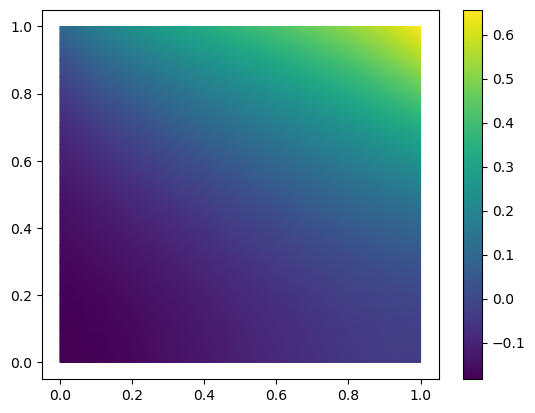

In [9]:
# Plot the numerical solution
fig, ax = plt.subplots()
q = tripcolor(u_h_alg, axes=ax)
fig.colorbar(q)

## Exercise 2

Laplace problem in the unit square domain $\Omega = {(0,1)}^2$, with mixed boundary conditions:
\begin{equation*}
  \begin{cases}
    -\Delta u = 0, \qquad & \text{in }\Omega, \\
    u  = y(1-y) \qquad & \text{on }\Gamma_1 = \{x=0, 0\leq y\leq 1\},
    \\
    u = 0 \qquad & \text{on }\Gamma_2 = \{x=1, 0\leq y\leq 1\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 1 \qquad & \text{on }\Gamma_3 = \{0\leq x\leq 1, y=0\},
    \\
    \nabla u\cdot{\boldsymbol{n}} = 0 \qquad & \text{on }\Gamma_4 = \{0\leq x\leq 1, y=1\}.\end{cases}
\end{equation*}


In [10]:
# Build the mesh
N = 3
mesh = UnitSquareMesh(N, N, diagonal='right')

# Define a discrete function space
V = FunctionSpace(mesh, 'P', 1)

# Define trial and test functions as belonging to the space
u = TrialFunction(V)
v = TestFunction(V)

# Define the boundary data
x = SpatialCoordinate(mesh)
gD1 = x[1]*(1-x[1])
gD2 = Constant(0.0)

# Solver parameters
params = {'ksp_type': 'preonly', 'pc_type': 'lu'}

In [11]:
### Strong imposition of Dirichlet boundary conditions

bc1 = DirichletBC(V, gD1, 1)
bc2 = DirichletBC(V, gD2, 2)
bcs = (bc1, bc2)

# Define the variational problem: bilinear form and rhs
a = dot(grad(u), grad(v)) * dx
L = v*ds(3)

u_h_strong = Function(V)
solve(a == L, u_h_strong, bcs=bcs, solver_parameters=params)

point 4 - Algebraic formulation

In [14]:
A = assemble(a)
rhs = assemble(L)
AwithBC = assemble(a,bcs=bcs)
rhswithBC = assemble(L,bcs=bcs)

# print options
np.set_printoptions(precision=1)
np.set_printoptions(linewidth=400)
np.set_printoptions(suppress=True)

# print utility functions
def print_matrix(A):
  print(A.M.values)
  print()
def print_rhs(b):
  print(b.dat.data_ro)
  print()

print_matrix(A)
print_rhs(rhs)

print_matrix(AwithBC) # Dirichlet rows and columns replaced by identity
print_rhs(rhswithBC)  # Dirichlet entries replaced by 0

[[ 2.   0.  -0.5 -1.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [ 0.   2.  -0.5 -1.   0.  -0.5  0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5 -0.5  1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-1.  -1.   0.   4.   0.   0.  -1.  -1.   0.   0.   0.   0.   0.   0.   0.   0. ]
 [-0.5  0.   0.   0.   2.   0.  -1.   0.  -0.5  0.   0.   0.   0.   0.   0.   0. ]
 [ 0.  -0.5  0.   0.   0.   2.   0.  -1.   0.  -0.5  0.   0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -1.  -1.   0.   4.   0.   0.   0.  -1.  -1.   0.   0.   0.   0. ]
 [ 0.   0.   0.  -1.   0.  -1.   0.   4.   0.   0.   0.  -1.  -1.   0.   0.   0. ]
 [ 0.   0.   0.   0.  -0.5  0.   0.   0.   1.   0.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.  -0.5  0.   0.   0.   1.   0.   0.  -0.5  0.   0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -1.   0.  -0.5  0.   2.   0.   0.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.   0.   0.  -1.  -1.   0.   0.   0.   4.   0.  -1.  -1.   0. ]
 [ 0

In [17]:
# 1. no Dirichlet BC: solution blow-up
solver=LinearSolver(A)
uh_alg = Function(V)
solver.solve(uh_alg, rhs)
print(uh_alg.dat.data_ro)

# 2. Dirichlet BC in A: the matrix object "knows" how lift data correctly
solver = LinearSolver(AwithBC)
uh_alg = Function(V)
solver.solve(uh_alg, rhs)
print(uh_alg.dat.data_ro) 

# 3. Dirichlet BC in A and in rhs:
#    the matrix object already "knows" how lift data correctly,
#    so the result is the same as point 2
solver = LinearSolver(AwithBC)
uh_alg = Function(V)
solver.solve(uh_alg, rhswithBC)
print(uh_alg.dat.data_ro)


[-2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14 -2.3e+14]
[0.2 0.1 0.  0.2 0.2 0.1 0.2 0.1 0.  0.  0.4 0.2 0.  0.3 0.  0. ]
[0.2 0.1 0.  0.2 0.2 0.1 0.2 0.1 0.  0.  0.4 0.2 0.  0.3 0.  0. ]
